# NOTAS DE CLASE: Implementación de Cámara de Rotación Pura (C++)

Para este requerimiento, utilizaremos la clase **APawn**.

### ¿Por qué APawn y no ACharacter?
*   **ACharacter:** Incluye por defecto una cápsula de colisión y un `CharacterMovementComponent`. Está diseñado para personajes que caminan, saltan y tienen gravedad. Es demasiado "pesado" para una cámara fija.
*   **APawn:** Es la clase base más sencilla que puede ser poseída por un jugador. Al no incluir lógica de movimiento físico predefinida, es ideal para cámaras estáticas o controles personalizados, consumiendo menos recursos.

---

### 1. Cabecera (MiraSolo.h)

```cpp
#pragma once

#include "CoreMinimal.h"
#include "GameFramework/Pawn.h"
#include "Camera/CameraComponent.h"
#include "MiraSolo.generated.h"

UCLASS()
class MI_PROYECTO_API AMiraSolo : public APawn
{
    GENERATED_BODY()

public:
    AMiraSolo();

protected:
    virtual void BeginPlay() override;

    // Componente fundamental para la visualización del jugador
    UPROPERTY(VisibleAnywhere, BlueprintReadOnly, Category = "Cámara")
    UCameraComponent* CameraComp;

public:	
    // Función para mapear las teclas/ratón a acciones de código
    virtual void SetupPlayerInputComponent(class UInputComponent* PlayerInputComponent) override;

    // Métodos para rotación
    void RotateYaw(float Value);   // Rotación horizontal (Eje Z)
    void RotatePitch(float Value); // Rotación vertical (Eje Y)
};
```

---

### 2. Implementación (MiraSolo.cpp)

```cpp
#include "MiraSolo.h"

AMiraSolo::AMiraSolo()
{
    // Desactivamos el Tick ya que la rotación se ejecuta por Input asíncrono
    PrimaryActorTick.bCanEverTick = false;

    // Definición de jerarquía básica
    RootComponent = CreateDefaultSubobject<USceneComponent>(TEXT("Root"));
    CameraComp = CreateDefaultSubobject<UCameraComponent>(TEXT("Camera"));
    CameraComp->SetupAttachment(RootComponent);

    // NOTA ACLARATORIA: bUsePawnControlRotation es Vital. 
    // Sin esto, la cámara no seguirá el movimiento del controlador del ratón.
    CameraComp->bUsePawnControlRotation = true;
    bUseControllerRotationPitch = true;
    bUseControllerRotationYaw = true;
}

void AMiraSolo::BeginPlay()
{
    Super::BeginPlay();
}

void AMiraSolo::SetupPlayerInputComponent(UInputComponent* PlayerInputComponent)
{
    Super::SetupPlayerInputComponent(PlayerInputComponent);

    // Los nombres "Turn" y "LookUp" deben coincidir con Project Settings -> Input
    PlayerInputComponent->BindAxis("Turn", this, &AMiraSolo::RotateYaw);
    PlayerInputComponent->BindAxis("LookUp", this, &AMiraSolo::RotatePitch);
}

void AMiraSolo::RotateYaw(float Value)
{
    // Añade entrada de rotación en el eje horizontal
    AddControllerYawInput(Value);
}

void AMiraSolo::RotatePitch(float Value)
{
    // Añade entrada de rotación en el eje vertical
    AddControllerPitchInput(Value);
}
```

---


### 3. Notas Aclaratorias Finales

*   **Bloqueo de Ángulo (Pitch):** Por defecto, Unreal limita la rotación vertical entre -90 y 90 grados para evitar que la cámara se invierta. Esto se configura en el `PlayerCameraManager`.
*   **Inversión de Eje:** Si al mover el mouse hacia arriba la cámara baja, se debe cambiar el valor de `Scale` a `-1.0` en los `Axis Mappings` del motor, no necesariamente en el código.
*   **Sensibilidad:** El valor `Value` recibido en las funciones de rotación depende de la sensibilidad configurada en el `PlayerController`.


---
# NOTAS DE CLASE: Análisis de Control de Cámara

Efectivamente, **este código maneja la cámara con el mouse** mediante la delegación de la rotación al controlador del jugador (`PlayerController`).

### ¿Cómo funciona técnicamente?

El flujo de control sigue este camino:
1. **Entrada Física:** El usuario mueve el mouse (Eje X o Eje Y).
2. **Mapeo de Ejes:** Unreal detecta los nombres `"Turn"` y `"LookUp"` que vinculamos en `SetupPlayerInputComponent`.
3. **Delegación al Controlador:** Las funciones `AddControllerYawInput` y `AddControllerPitchInput` no rotan el `Pawn` directamente de forma manual, sino que le dicen al **Controller** (el "cerebro" del jugador) que cambie su orientación.
4. **Sincronización de Componente:** Al haber marcado `CameraComp->bUsePawnControlRotation = true;`, el componente de la cámara se "ancla" automáticamente a la rotación del controlador.

---

### Notas Aclaratorias sobre el manejo de rotación:

*   **Yaw (Horizontal):** Controla el giro hacia los lados (como decir "no" con la cabeza). En el código se usa `AddControllerYawInput`.
*   **Pitch (Vertical):** Controla la inclinación arriba y abajo. En el código se usa `AddControllerPitchInput`.
*   **Independencia de FPS:** A diferencia del código de las figuras geométricas que analizamos antes (donde multiplicábamos por `DeltaTime`), las funciones de `AddControllerInput` ya están optimizadas internamente por Unreal para que la sensibilidad sea consistente independientemente de los cuadros por segundo.

---

### Verificación de Configuración Crítica

Para que el mouse responda, es obligatorio que en el constructor existan estas líneas, de lo contrario la cámara se quedará estática:

```cpp
// Sin estas 3 líneas, el mouse no tendrá efecto sobre la vista
CameraComp->bUsePawnControlRotation = true; // La cámara sigue al control
bUseControllerRotationPitch = true;        // El Pawn acepta rotación vertical
bUseControllerRotationYaw = true;          // El Pawn acepta rotación horizontal
```


# NOTAS DE CLASE: Escena con Múltiples Geometrías y Cámara de Rotación

Es totalmente posible colocar las tres geometrías en la misma escena. En Unreal Engine, tienes dos formas principales de lograrlo dependiendo de si quieres que funcionen como un "set" inseparable o como objetos independientes.

### Opción A: Un solo Actor con Múltiples Componentes (Jerarquía)
Esta es la opción que ya tienes en tu código original. Utilizas **un solo Actor** (`AMiGeometria`) que actúa como un contenedor para tres **Componentes** (`UStaticMeshComponent`).

*   **Ventaja:** Si mueves el Actor en el nivel, las tres figuras se mueven juntas manteniendo su distancia relativa.
*   **Ideal para:** Objetos compuestos (ej. una mesa con cuatro patas, un coche con cuatro ruedas).

### Opción B: Múltiples Actores Independientes
Podrías separar el Cubo, la Esfera y el Cono en **clases de C++ diferentes** (ej. `ACuboActor`, `AEsferaActor`, etc.).

*   **Ventaja:** Puedes colocar cada figura en cualquier lugar del nivel de forma independiente, borrarlas por separado o darles comportamientos distintos.
*   **Ideal para:** Objetos que el jugador puede mover individualmente o que aparecen en distintos puntos del mapa.

---

### Notas Aclaratorias sobre la Clase a Utilizar

Para combinar todo en una sola escena de práctica, lo más limpio es utilizar la clase **`APawn`** para tu cámara y **`AActor`** para tus geometrías.


| Clase | Uso en tu proyecto | Justificación técnica |
| :--- | :--- | :--- |
| **APawn** | La Cámara | Es la clase mínima que permite "Posesión" por parte del jugador y recepción de **Inputs** (mouse/teclado). |
| **AActor** | Geometrías | Es la unidad básica que puede existir en el mundo. No requiere ser poseída, solo necesita un `Transform` y una `Mesh`. |

---

### Código: Integración de Geometrías en el Mundo (Ejemplo Independiente)

Si quieres que las geometrías "vivan" en la misma escena que tu cámara de rotación, simplemente arrástralas desde el **Content Browser** al nivel donde está tu `AMiraSolo`.

```cpp
// --- Notas sobre la posición relativa en el Constructor de AMiGeometria ---
// Para que no aparezcan una encima de otra en la escena:

AMiGeometria::AMiGeometria()
{
    RootComponent = CreateDefaultSubobject<USceneComponent>(TEXT("Raiz"));

    // El cubo se queda en el origen (0,0,0) relativo a la raíz
    CuboMesh->SetupAttachment(RootComponent);

    // La esfera se desplaza 200 unidades a la derecha
    EsferaMesh->SetRelativeLocation(FVector(200.0f, 0.0f, 0.0f));
    EsferaMesh->SetupAttachment(RootComponent);

    // El cono se desplaza 200 unidades a la izquierda
    ConoMesh->SetRelativeLocation(FVector(-200.0f, 0.0f, 0.0f));
    ConoMesh->SetupAttachment(RootComponent);
}
```

### Resumen de la Escena Final
1.  **Actor 1 (AMiraSolo):** Gestiona tu vista en primera persona y la rotación del mouse.
2.  **Actor 2 (AMiGeometria):** Contiene el grupo de figuras animadas (rotación y flotación).
3.  **Resultado:** Al darle a "Play", verás el grupo de figuras frente a ti y podrás girar tu cabeza para observarlas desde distintos ángulos.

# NOTAS DE CLASE: Proyecto de Geometrías Animadas con Cámara Rotativa (C++)

Este código integra los dos elementos discutidos: un **Pawn** que controla la visión del jugador mediante el ratón y un **Actor** que gestiona tres figuras geométricas con movimientos independientes.

---

### ACTOR 1: El Observador (Cámara de Rotación)
**Tipo de clase:** `APawn`
**Función:** Actúa como el punto de vista del jugador. No tiene cuerpo físico, solo una cámara que gira en su eje (Yaw y Pitch) para observar el entorno.

#### MiraSolo.h
```cpp
#pragma once

#include "CoreMinimal.h"
#include "GameFramework/Pawn.h"
#include "Camera/CameraComponent.h"
#include "MiraSolo.generated.h"

UCLASS()
class GEOMETRIAS_API AMiraSolo : public APawn
{
	GENERATED_BODY()

public:
	AMiraSolo();

protected:
	virtual void BeginPlay() override;

	UPROPERTY(VisibleAnywhere, BlueprintReadOnly, Category = "Cámara")
	UCameraComponent* CameraComp;

public:	
	virtual void SetupPlayerInputComponent(class UInputComponent* PlayerInputComponent) override;

	void RotateYaw(float Value);
	void RotatePitch(float Value);
};
```

#### MiraSolo.cpp
```cpp
#include "MiraSolo.h"

AMiraSolo::AMiraSolo()
{
	PrimaryActorTick.bCanEverTick = false;

	// Jerarquía: Una raíz simple y la cámara adjunta
	RootComponent = CreateDefaultSubobject<USceneComponent>(TEXT("Root"));
	CameraComp = CreateDefaultSubobject<UCameraComponent>(TEXT("Camera"));
	CameraComp->SetupAttachment(RootComponent);

	// Configuración de control: Sincroniza la cámara con el ratón
	CameraComp->bUsePawnControlRotation = true;
	bUseControllerRotationPitch = true;
	bUseControllerRotationYaw = true;
}

void AMiraSolo::BeginPlay() { Super::BeginPlay(); }

void AMiraSolo::SetupPlayerInputComponent(UInputComponent* PlayerInputComponent)
{
	Super::SetupPlayerInputComponent(PlayerInputComponent);
	PlayerInputComponent->BindAxis("Turn", this, &AMiraSolo::RotateYaw);
	PlayerInputComponent->BindAxis("LookUp", this, &AMiraSolo::RotatePitch);
}

void AMiraSolo::RotateYaw(float Value) { AddControllerYawInput(Value); }
void AMiraSolo::RotatePitch(float Value) { AddControllerPitchInput(Value); }
```

---

### ACTOR 2: El Exhibidor (Grupo de Geometrías)
**Tipo de clase:** `AActor`
**Función:** Un objeto en el mundo que contiene tres mallas estáticas (Cubo, Esfera, Cono) y procesa su animación (rotación y flotación) en el `Tick`.

#### MiGeometria.h
```cpp
#pragma once

#include "CoreMinimal.h"
#include "GameFramework/Actor.h"
#include "Components/StaticMeshComponent.h"
#include "MiGeometria.generated.h"

UCLASS()
class GEOMETRIAS_API AMiGeometria : public AActor
{
	GENERATED_BODY()
	
public:	
	AMiGeometria();

protected:
	virtual void BeginPlay() override;

public:	
	virtual void Tick(float DeltaTime) override;

	// Componentes para las figuras
	UPROPERTY(VisibleAnywhere, Category = "Figuras")
	UStaticMeshComponent* CuboMesh;

	UPROPERTY(VisibleAnywhere, Category = "Figuras")
	UStaticMeshComponent* EsferaMesh;

	UPROPERTY(VisibleAnywhere, Category = "Figuras")
	UStaticMeshComponent* ConoMesh;
};
```

#### MiGeometria.cpp
```cpp
#include "MiGeometria.h"
#include "UObject/ConstructorHelpers.h"

AMiGeometria::AMiGeometria()
{
	PrimaryActorTick.bCanEverTick = true;

	RootComponent = CreateDefaultSubobject<USceneComponent>(TEXT("Root"));

	// Carga de Assets Básicos del Motor
	static ConstructorHelpers::FObjectFinder<UStaticMesh> MeshCubo(TEXT("/Engine/BasicShapes/Cube.Cube"));
	static ConstructorHelpers::FObjectFinder<UStaticMesh> MeshEsfera(TEXT("/Engine/BasicShapes/Sphere.Sphere"));
	static ConstructorHelpers::FObjectFinder<UStaticMesh> MeshCono(TEXT("/Engine/BasicShapes/Cone.Cone"));

	// Configuración del Cubo (Centro)
	CuboMesh = CreateDefaultSubobject<UStaticMeshComponent>(TEXT("Cubo"));
	CuboMesh->SetupAttachment(RootComponent);
	if (MeshCubo.Succeeded()) CuboMesh->SetStaticMesh(MeshCubo.Object);

	// Configuración de la Esfera (Derecha)
	EsferaMesh = CreateDefaultSubobject<UStaticMeshComponent>(TEXT("Esfera"));
	EsferaMesh->SetupAttachment(RootComponent);
	EsferaMesh->SetRelativeLocation(FVector(200.0f, 0.0f, 0.0f));
	if (MeshEsfera.Succeeded()) EsferaMesh->SetStaticMesh(MeshEsfera.Object);

	// Configuración del Cono (Izquierda)
	ConoMesh = CreateDefaultSubobject<UStaticMeshComponent>(TEXT("Cono"));
	ConoMesh->SetupAttachment(RootComponent);
	ConoMesh->SetRelativeLocation(FVector(-200.0f, 0.0f, 0.0f));
	if (MeshCono.Succeeded()) ConoMesh->SetStaticMesh(MeshCono.Object);
}

void AMiGeometria::BeginPlay() { Super::BeginPlay(); }

void AMiGeometria::Tick(float DeltaTime)
{
	Super::Tick(DeltaTime);

	// Animación 1: El Cubo rota constantemente
	CuboMesh->AddRelativeRotation(FRotator(0.0f, 60.0f * DeltaTime, 0.0f));

	// Animación 2: La Esfera flota verticalmente usando Seno
	float Tiempo = GetWorld()->GetTimeSeconds();
	float Flotacion = FMath::Sin(Tiempo * 3.0f) * 0.8f; 
	EsferaMesh->AddRelativeLocation(FVector(0.0f, 0.0f, Flotacion));
}
```

---

### NOTAS ACLARATORIAS FINALES

1.  **Ensamblaje en la Escena:** 
    *   Arrastra `AMiGeometria` al nivel frente a la posición de inicio.
    *   Arrastra `AMiraSolo` al nivel.
    *   En el panel **Details** de `AMiraSolo`, busca `Auto Possess Player` y cámbialo a `Player 0`.
2.  **Configuración de Input:** 
    *   Asegúrate de que en `Project Settings > Input`, los nombres **Turn** (Mouse X) y **LookUp** (Mouse Y) estén creados exactamente así.
3.  **Dependencias:** 
    *   Recuerda sustituir `GEOMETRIAS_API` por el nombre de tu proyecto en mayúsculas si es diferente.


## 💡 Puntos a destacar de tu código:

- **Jerarquía de Componentes**: El uso de USceneComponent como RootComponent es una práctica ideal; te permite mover el Actor completo en el editor sin afectar los offsets individuales de las mallas (CuboMesh, EsferaMesh, etc.).
- **Optimización**: En AMiraSolo, pusiste bCanEverTick = false. Esto es excelente para el rendimiento, ya que los Pawns de cámara no suelen necesitar lógica por frame si el input ya maneja la rotación.
- **Matemáticas de Animación**: El uso de FMath::Sin para la flotación es el estándar para movimientos cíclicos suaves.

### ⚠️ Sugerencia rápida para el Cono:

Noté que el Cono (ConoMesh) no tiene animación en el Tick. Si quieres que haga algo distinto para completar el set, podrías añadirle un "latido" (escala) añadiendo esto al final del Tick:

### MiGeometria.cpp (Modificacion)
```cpp
// Animación 3: El Cono pulsa (cambia de tamaño)
float EscalaPulsante = 1.0f + (FMath::Sin(Tiempo * 2.0f) * 0.2f);
ConoMesh->SetRelativeScale3D(FVector(EscalaPulsante));
```

### 🛠️ Recordatorio de Compilación:
Si al compilar te da error en ConstructorHelpers, asegúrate de incluir #include "UObject/ConstructorHelpers.h" en la parte superior del .cpp de MiGeometria (aunque ya lo tienes anotado, es el error más común en Unreal).


# Ya tienes construida la **base técnica** necesaria para un sistema de disparo en primera persona (FPS).
Para convertir este proyecto en un shooter, solo tendrías que añadir tres pilares sobre lo que ya hiciste:
- ### 1. Evolución del Pawn (MiraSolo)
  Actualmente tu cámara flota sola. Para un FPS:
  - **Cuerpo físico**: Tendrías que añadir un UCapsuleComponent (para colisiones) y un USkeletalMeshComponent (los brazos y el arma).
  - **Movimiento**: Deberías añadir funciones para moverte adelante/atrás y a los lados (AddMovementInput), vinculándolas a las teclas WASD.

- ### 2. El Mecanismo de Disparo
  Tienes dos formas clásicas de hacerlo en C++ partiendo de tu código:

  - **Line Tracing (Raycast)**: Es lo más común. Al hacer clic, el código lanza una "línea invisible" desde el centro de la cámara hacia adelante. Si choca con MiGeometria, detectas el impacto.
  - **Proyectiles físicos**: Creas una nueva clase AProjectile que nazca en la posición del arma y salga disparada con una velocidad inicial.

- ### 3. Interacción con los Objetos
  Como ya tienes el Tick animando las figuras en MiGeometria.cpp, podrías añadir una función para que, al recibir un disparo, la animación cambie o el objeto se destruya:
```cpp
void AMiGeometria::RecibirDisparo() {
    CuboMesh->AddImpulse(FVector(0,0,1000)); // ¡El cubo salta al recibir un tiro!
}
```
### ¿Qué te falta para dar el siguiente paso?
El sistema de **Input** que ya configuraste para el ratón es exactamente el mismo que se usa en los juegos profesionales. Solo tendrías que registrar una nueva acción en SetupPlayerInputComponent:
```cpp
PlayerInputComponent->BindAction("Fire", IE_Pressed, this, &AMiraSolo::OnFire);

```


# Antes de meterse a balística
¡Ese es el enfoque correcto! Domina primero la **jerarquía de componentes** y la lógica del Tick antes de meterte en líos de balística.<br>
Un último consejo antes de que te lances al código:<br>
Como vas a usar ConstructorHelpers para cargar los modelos básicos (Cube, Sphere, Cone), asegúrate de que tu proyecto sea **C++ con contenido inicial (Starter Content)** o que el motor tenga acceso a la carpeta /Engine/BasicShapes/. Si al compilar ves que las figuras no aparecen en el nivel (pero el Actor sí está ahí), suele ser porque la ruta del asset cambió ligeramente entre versiones de Unreal.

### Pasos inmediatos para ti:
  1. Crea las clases desde el Editor (**New C++ Class**).
  2. Cierra el motor.
  3. Copia y pega el código en tu IDE (VS Code o Visual Studio).
  4. **Compila desde el IDE** antes de abrir el motor de nuevo.




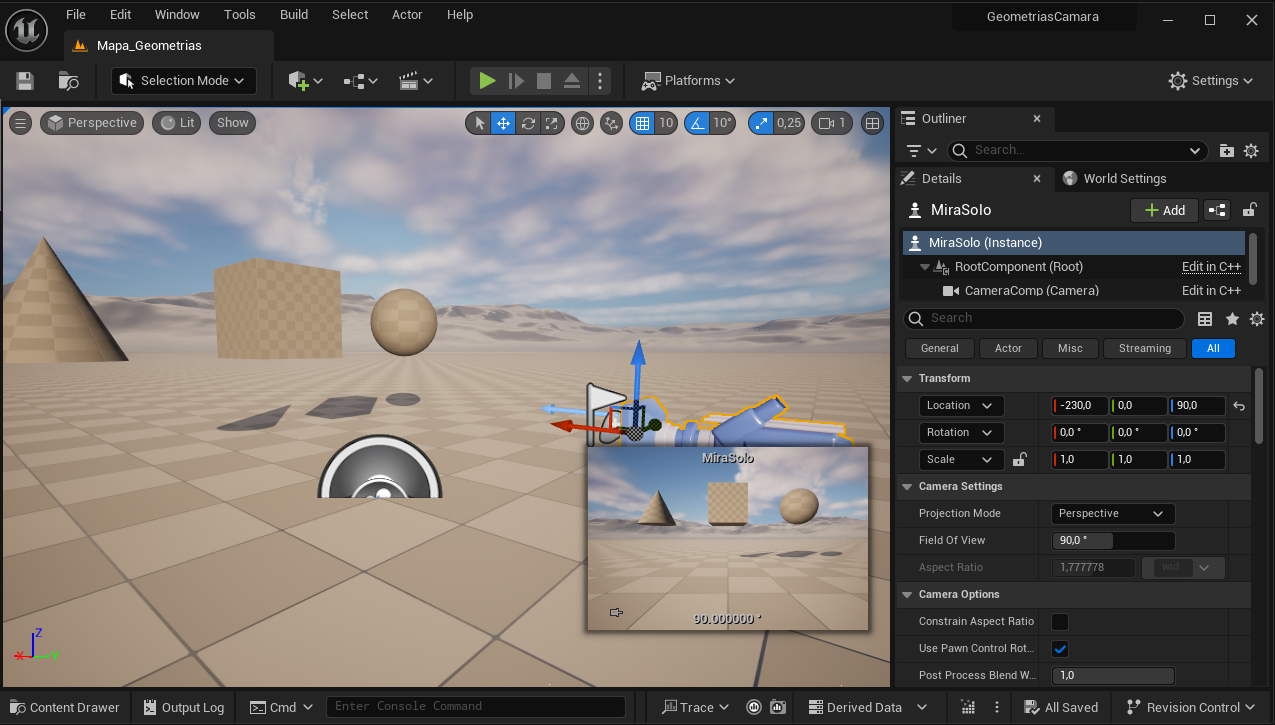


# Archivo: MiraSolo.h

```cpp
#pragma once

#include "CoreMinimal.h"
#include "GameFramework/Pawn.h"
#include "Camera/CameraComponent.h"
#include "MiraSolo.generated.h"

UCLASS()
class GEOMETRIASCAMARA_API AMiraSolo : public APawn
{
	GENERATED_BODY()

public:
	AMiraSolo();

protected:
	virtual void BeginPlay() override;

	UPROPERTY(VisibleAnywhere, BlueprintReadOnly, Category = "Cámara")
	UCameraComponent* CameraComp;

public:
	virtual void SetupPlayerInputComponent(class UInputComponent* PlayerInputComponent) override;

	void RotateYaw(float Value);
	void RotatePitch(float Value);
};
```

# Explicación Completa — MiraSolo.h

Este archivo define una clase llamada `AMiraSolo` que hereda de `APawn`.  
El propósito de esta clase es crear una cámara controlable por el jugador mediante movimiento del mouse.

---

## `#pragma once`

```cpp
#pragma once
```

Evita que el archivo sea incluido múltiples veces durante la compilación.

Sin esto podrían ocurrir errores de redefinición de clases.

---

## Includes

```cpp
#include "CoreMinimal.h"
```

Incluye los elementos básicos del motor Unreal Engine:
- Tipos primitivos
- Matemáticas
- Macros
- Utilidades

---

```cpp
#include "GameFramework/Pawn.h"
```

Permite heredar de `APawn`.

Un `Pawn` representa cualquier objeto controlable por:
- Jugador
- Inteligencia Artificial

Ejemplos:
- Personajes
- Vehículos
- Cámaras

---

```cpp
#include "Camera/CameraComponent.h"
```

Permite usar cámaras dentro del actor.

---

```cpp
#include "MiraSolo.generated.h"
```

Archivo generado automáticamente por Unreal Header Tool.

Necesario para:
- Reflection System
- Blueprints
- Serialización
- Garbage Collection

Siempre debe ser el último include.

---

## Declaración de clase

```cpp
UCLASS()
class GEOMETRIASCAMARA_API AMiraSolo : public APawn
```

### `UCLASS()`

Registra la clase dentro del sistema de Unreal.

---

### `GEOMETRIASCAMARA_API`

Permite exportar/importar la clase dentro del módulo del proyecto.

---

### `public APawn`

Indica que la clase hereda de `APawn`.

---

## `GENERATED_BODY()`

```cpp
GENERATED_BODY()
```

Genera automáticamente:
- Código interno
- Reflection
- Integración con Blueprints

---

## Constructor

```cpp
AMiraSolo();
```

Función que inicializa el actor cuando es creado.

---

## `BeginPlay`

```cpp
virtual void BeginPlay() override;
```

Se ejecuta cuando comienza el juego.

---

## Cámara

```cpp
UPROPERTY(VisibleAnywhere, BlueprintReadOnly, Category = "Cámara")
UCameraComponent* CameraComp;
```

Define un componente de cámara.

### `VisibleAnywhere`
Visible en el editor.

### `BlueprintReadOnly`
Puede leerse desde Blueprints.

### `Category`
Organiza la variable en el editor.

---

## Setup Input

```cpp
virtual void SetupPlayerInputComponent(class UInputComponent* PlayerInputComponent) override;
```

Aquí se conectan controles:
- Mouse
- Teclado
- Gamepad

---

## Funciones de rotación

```cpp
void RotateYaw(float Value);
void RotatePitch(float Value);
```

Permiten mover:
- Cámara horizontalmente
- Cámara verticalmente

---

# Archivo: MiraSolo.cpp

```cpp
#include "MiraSolo.h"
#include "Components/InputComponent.h"
#include "GameFramework/PlayerController.h"
#include "Kismet/GameplayStatics.h"
#include "Kismet/KismetMathLibrary.h"
#include "TimerManager.h"

AMiraSolo::AMiraSolo()
{
	PrimaryActorTick.bCanEverTick = false;

	RootComponent = CreateDefaultSubobject<USceneComponent>(TEXT("Root"));
	CameraComp = CreateDefaultSubobject<UCameraComponent>(TEXT("Camera"));
	CameraComp->SetupAttachment(RootComponent);

	CameraComp->bUsePawnControlRotation = true;
	bUseControllerRotationPitch = true;
	bUseControllerRotationYaw = true;
}

void AMiraSolo::BeginPlay()
{
	Super::BeginPlay();

	// Timer para forzar la vista a las geometrías tras 0.2 segundos
	FTimerHandle TimerHandle;
	GetWorldTimerManager().SetTimer(TimerHandle, [this]()
		{
			// Busca cualquier actor en el mapa (el exhibidor)
			AActor* GeometriaActor = UGameplayStatics::GetActorOfClass(GetWorld(), AActor::StaticClass());

			if (GetController())
			{
				FRotator RotacionFinal = GetActorRotation();

				if (GeometriaActor)
				{
					RotacionFinal = UKismetMathLibrary::FindLookAtRotation(GetActorLocation(), GeometriaActor->GetActorLocation());
				}

				GetController()->SetControlRotation(RotacionFinal);
				SetActorRotation(RotacionFinal);

				if (APlayerController* PC = Cast<APlayerController>(GetController()))
				{
					PC->RotationInput = FRotator::ZeroRotator;
				}
			}
		}, 0.2f, false);
}

void AMiraSolo::SetupPlayerInputComponent(UInputComponent* PlayerInputComponent)
{
	Super::SetupPlayerInputComponent(PlayerInputComponent);
	PlayerInputComponent->BindAxis("Turn", this, &AMiraSolo::RotateYaw);
	PlayerInputComponent->BindAxis("LookUp", this, &AMiraSolo::RotatePitch);
}

void AMiraSolo::RotateYaw(float Value)
{
	AddControllerYawInput(Value);
}

void AMiraSolo::RotatePitch(float Value)
{
	AddControllerPitchInput(Value);
}
```

# Explicación Completa — MiraSolo.cpp

Este archivo implementa toda la lógica funcional de la cámara.

---

## Includes

```cpp
#include "Components/InputComponent.h"
```

Permite usar controles de entrada.

---

```cpp
#include "GameFramework/PlayerController.h"
```

Permite acceder al controlador del jugador.

---

```cpp
#include "Kismet/GameplayStatics.h"
```

Contiene funciones globales útiles.

---

```cpp
#include "Kismet/KismetMathLibrary.h"
```

Incluye funciones matemáticas avanzadas.

---

```cpp
#include "TimerManager.h"
```

Permite crear timers.

---

# Constructor

```cpp
AMiraSolo::AMiraSolo()
```

Inicializa la cámara.

---

## Desactivar Tick

```cpp
PrimaryActorTick.bCanEverTick = false;
```

La cámara no necesita actualizarse cada frame.

Esto optimiza rendimiento.

---

## Root Component

```cpp
RootComponent = CreateDefaultSubobject<USceneComponent>(TEXT("Root"));
```

Crea el componente raíz.

Todos los demás componentes se conectan aquí.

---

## Cámara

```cpp
CameraComp = CreateDefaultSubobject<UCameraComponent>(TEXT("Camera"));
CameraComp->SetupAttachment(RootComponent);
```

Crea una cámara y la conecta al root.

---

## Rotación controlada por el jugador

```cpp
CameraComp->bUsePawnControlRotation = true;
```

Hace que la cámara siga la rotación del controlador.

---

```cpp
bUseControllerRotationPitch = true;
bUseControllerRotationYaw = true;
```

Permite usar:
- Movimiento horizontal del mouse
- Movimiento vertical del mouse

---

# BeginPlay

```cpp
void AMiraSolo::BeginPlay()
```

Se ejecuta al iniciar el juego.

---

## Timer

```cpp
FTimerHandle TimerHandle;
```

Variable que controla el temporizador.

---

## SetTimer

```cpp
GetWorldTimerManager().SetTimer(...)
```

Ejecuta una función después de cierto tiempo.

En este caso:
- Espera 0.2 segundos
- Luego orienta la cámara

---

## Lambda Function

```cpp
[this]()
```

Función anónima.

Captura la clase actual para usar sus variables.

---

## Buscar Actor

```cpp
AActor* GeometriaActor = UGameplayStatics::GetActorOfClass(GetWorld(), AActor::StaticClass());
```

Busca un actor dentro del mapa.

---

## Verificar Controller

```cpp
if (GetController())
```

Comprueba que el Pawn tenga controlador válido.

---

## Rotación Inicial

```cpp
FRotator RotacionFinal = GetActorRotation();
```

Obtiene la rotación actual.

---

## Look At Rotation

```cpp
UKismetMathLibrary::FindLookAtRotation(...)
```

Calcula una rotación para mirar hacia un punto específico.

---

## Aplicar Rotación

```cpp
GetController()->SetControlRotation(RotacionFinal);
```

Rota el controlador.

---

```cpp
SetActorRotation(RotacionFinal);
```

Rota físicamente el Pawn.

---

## Reinicio de Input

```cpp
PC->RotationInput = FRotator::ZeroRotator;
```

Evita acumulación de movimiento inicial del mouse.

---

# Setup Input

```cpp
PlayerInputComponent->BindAxis("Turn", this, &AMiraSolo::RotateYaw);
```

Conecta el eje horizontal.

---

```cpp
PlayerInputComponent->BindAxis("LookUp", this, &AMiraSolo::RotatePitch);
```

Conecta el eje vertical.

---

# Rotación Horizontal

```cpp
AddControllerYawInput(Value);
```

Gira la cámara horizontalmente.

---

# Rotación Vertical

```cpp
AddControllerPitchInput(Value);
```

Gira la cámara verticalmente.

---

# Archivo: MiGeometria.h

```cpp
#pragma once

#include "CoreMinimal.h"
#include "GameFramework/Actor.h"
#include "Components/StaticMeshComponent.h"
#include "MiGeometria.generated.h"

UCLASS()
class GEOMETRIASCAMARA_API AMiGeometria : public AActor
{
	GENERATED_BODY()

public:
	AMiGeometria();

protected:
	virtual void BeginPlay() override;

public:
	virtual void Tick(float DeltaTime) override;

	UPROPERTY(VisibleAnywhere, Category = "Figuras")
	UStaticMeshComponent* CuboMesh;

	UPROPERTY(VisibleAnywhere, Category = "Figuras")
	UStaticMeshComponent* EsferaMesh;

	UPROPERTY(VisibleAnywhere, Category = "Figuras")
	UStaticMeshComponent* ConoMesh;
};
```

# Explicación Completa — MiGeometria.h

Esta clase genera las figuras geométricas del proyecto.

---

## Herencia

```cpp
public AActor
```

La clase hereda de `AActor`.

Un `Actor` representa cualquier objeto colocable en el mundo.

---

## Tick

```cpp
virtual void Tick(float DeltaTime) override;
```

Se ejecuta cada frame.

---

## Static Mesh Components

```cpp
UStaticMeshComponent* CuboMesh;
```

Representa un modelo 3D.

Se crean:
- Cubo
- Esfera
- Cono

---

# Archivo: MiGeometria.cpp

```cpp
#include "MiGeometria.h"
#include "UObject/ConstructorHelpers.h"
#include "Engine/StaticMesh.h"

AMiGeometria::AMiGeometria()
{
	PrimaryActorTick.bCanEverTick = true;
	RootComponent = CreateDefaultSubobject<USceneComponent>(TEXT("Root"));

	static ConstructorHelpers::FObjectFinder<UStaticMesh> MeshCubo(TEXT("/Engine/BasicShapes/Cube.Cube"));
	static ConstructorHelpers::FObjectFinder<UStaticMesh> MeshEsfera(TEXT("/Engine/BasicShapes/Sphere.Sphere"));
	static ConstructorHelpers::FObjectFinder<UStaticMesh> MeshCono(TEXT("/Engine/BasicShapes/Cone.Cone"));

	CuboMesh = CreateDefaultSubobject<UStaticMeshComponent>(TEXT("Cubo"));
	CuboMesh->SetupAttachment(RootComponent);
	if (MeshCubo.Succeeded()) CuboMesh->SetStaticMesh(MeshCubo.Object);

	EsferaMesh = CreateDefaultSubobject<UStaticMeshComponent>(TEXT("Esfera"));
	EsferaMesh->SetupAttachment(RootComponent);
	EsferaMesh->SetRelativeLocation(FVector(0.0f, 200.0f, 0.0f)); // Derecha
	if (MeshEsfera.Succeeded()) EsferaMesh->SetStaticMesh(MeshEsfera.Object);

	ConoMesh = CreateDefaultSubobject<UStaticMeshComponent>(TEXT("Cono"));
	ConoMesh->SetupAttachment(RootComponent);
	ConoMesh->SetRelativeLocation(FVector(0.0f, -200.0f, 0.0f)); // Izquierda
	if (MeshCono.Succeeded()) ConoMesh->SetStaticMesh(MeshCono.Object);
}

void AMiGeometria::BeginPlay()
{
	Super::BeginPlay();
}

void AMiGeometria::Tick(float DeltaTime)
{
	Super::Tick(DeltaTime);

	// Rotación del cubo
	CuboMesh->AddRelativeRotation(FRotator(0.0f, 60.0f * DeltaTime, 0.0f));

	// Flotación de la esfera
	float Tiempo = GetWorld()->GetTimeSeconds();
	float Flotacion = FMath::Sin(Tiempo * 3.0f) * 0.8f;
	EsferaMesh->AddRelativeLocation(FVector(0.0f, 0.0f, Flotacion));
}
```

# Explicación Completa — MiGeometria.cpp

Este archivo implementa la lógica visual de las figuras geométricas.

---

# Constructor

```cpp
AMiGeometria::AMiGeometria()
```

Inicializa las figuras.

---

# Activar Tick

```cpp
PrimaryActorTick.bCanEverTick = true;
```

Permite ejecutar lógica cada frame.

---

# Root Component

```cpp
RootComponent = CreateDefaultSubobject<USceneComponent>(TEXT("Root"));
```

Componente principal del actor.

---

# Cargar Meshes

```cpp
ConstructorHelpers::FObjectFinder<UStaticMesh>
```

Busca modelos dentro del motor.

---

# Rutas de Meshes

```cpp
TEXT("/Engine/BasicShapes/Cube.Cube")
```

Ruta interna del asset.

---

# Crear Cubo

```cpp
CuboMesh = CreateDefaultSubobject<UStaticMeshComponent>(TEXT("Cubo"));
```

Crea el componente del cubo.

---

# Adjuntar

```cpp
CuboMesh->SetupAttachment(RootComponent);
```

Conecta el cubo al root.

---

# Verificar carga

```cpp
if (MeshCubo.Succeeded())
```

Comprueba si el mesh se cargó correctamente.

---

# Posición de la Esfera

```cpp
EsferaMesh->SetRelativeLocation(FVector(0.0f, 200.0f, 0.0f));
```

Mueve la esfera a la derecha.

---

# Posición del Cono

```cpp
ConoMesh->SetRelativeLocation(FVector(0.0f, -200.0f, 0.0f));
```

Mueve el cono a la izquierda.

---

# Tick

```cpp
void AMiGeometria::Tick(float DeltaTime)
```

Se ejecuta continuamente.

---

# Rotación del Cubo

```cpp
CuboMesh->AddRelativeRotation(FRotator(0.0f, 60.0f * DeltaTime, 0.0f));
```

Hace rotar el cubo constantemente.

---

# DeltaTime

`DeltaTime` asegura que el movimiento:
- Sea fluido
- No dependa de FPS

---

# Tiempo Global

```cpp
float Tiempo = GetWorld()->GetTimeSeconds();
```

Obtiene el tiempo desde el inicio del juego.

---

# Función Sinusoidal

```cpp
FMath::Sin(Tiempo * 3.0f)
```

Genera oscilación suave.

---

# Flotación

```cpp
EsferaMesh->AddRelativeLocation(FVector(0.0f, 0.0f, Flotacion));
```

Mueve la esfera arriba y abajo.

---

# Flujo General del Proyecto

```text
Jugador mueve mouse
        ↓
Input Axis
        ↓
RotateYaw / RotatePitch
        ↓
Controller Rotation
        ↓
Camera Rotation
```

---

# Flujo de Animación

```text
Tick()
   ↓
Rotar Cubo
   ↓
Calcular seno
   ↓
Mover Esfera
```

---

# Incidencias Durante el Desarrollo

# 1. Cámara apuntando incorrectamente

## Problema

La cámara iniciaba mirando en dirección errónea.

## Causa

El `Controller` todavía no terminaba de inicializarse.

## Solución

Usar un timer:

```cpp
SetTimer(..., 0.2f, false);
```

---

# 2. Movimiento brusco inicial

## Problema

La cámara realizaba pequeños saltos.

## Causa

Acumulación de `RotationInput`.

## Solución

```cpp
PC->RotationInput = FRotator::ZeroRotator;
```

---

# 3. Actor incorrecto encontrado

## Problema

`GetActorOfClass()` podía devolver cualquier actor.

## Solución recomendada

Buscar directamente:

```cpp
AMiGeometria::StaticClass()
```

---

# 4. Movimiento dependiente del FPS

## Problema

Las animaciones variaban según FPS.

## Solución

Multiplicar movimientos por:

```cpp
DeltaTime
```

---

# Guardado del Proyecto

## Guardado Manual

```text
File → Save All
```

Guarda:
- Código
- Blueprints
- Assets
- Configuración

---

# Guardado de Mapas

## Método

```text
File → Save Current Level
```

o:

```text
Ctrl + S
```

---

# Ubicación de los mapas

```text
Content/Maps/
```

---

# Extensión de mapas

```text
.umap
```

---

# Guardado Automático

Unreal genera respaldos en:

```text
Saved/Autosaves/
```

---

# Compilación del Proyecto

## Desde Visual Studio

```text
Build Solution
```

---

## Desde Unreal

```text
Compile
```

---

# Carpetas importantes del proyecto

| Carpeta | Función |
|---|---|
| `Source/` | Código C++ |
| `Content/` | Assets |
| `Config/` | Configuración |
| `Saved/` | Logs y autosaves |
| `Intermediate/` | Archivos temporales |

---

# Conceptos Aprendidos

- Pawn
- Actor
- CameraComponent
- StaticMeshComponent
- Tick
- DeltaTime
- Rotaciones
- Input System
- Timers
- FVector
- FRotator
- ConstructorHelpers
- BeginPlay
- SetupPlayerInputComponent

---

# Resultado Final

El proyecto implementa:

- Cámara controlable por mouse
- Cámara enfocando automáticamente geometrías
- Cubo rotatorio
- Esfera flotante
- Cono estático
- Sistema de animaciones usando Tick
- Control de rotación mediante input del jugador

---